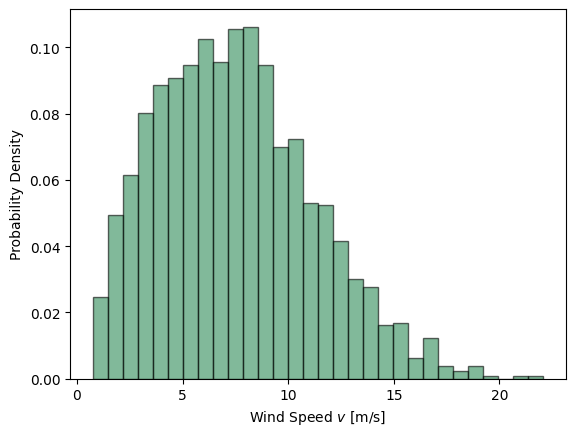

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import weibull_min


# 1. Generate Wind Speed Data (e.g., daily averages in meters/second)
true_shape_k = 2.2      # Typical wind profile (k ~ 2)
true_scale_lam = 8.5    # Solid wind farm location (scale ~ 8.5 m/s)
n_measurements = 365*5    # 5 years of daily data

np.random.seed(42)
# scipy's weibull_min uses 'c' for the shape parameter and 'scale' for lambda
wind_speeds = weibull_min.rvs(c=true_shape_k, scale=true_scale_lam, size=n_measurements)

# Plot the histogram
plt.hist(wind_speeds, bins=30, density=True, alpha=0.6, color='seagreen', edgecolor='black')
plt.xlabel("Wind Speed $v$ [m/s]")
plt.ylabel("Probability Density")
plt.show()
#@title { vertical-output: true}

In [ ]:
!pip install iminuit

In [ ]:
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL

# 2. Define the PDF wrapper for UnbinnedNLL
def weibull_pdf(v, k, lam):
    # We use scipy's built-in PDF for convenience
    return weibull_min.pdf(v, c=k, scale=lam)

# 3. Create the cost function
nll_wind = UnbinnedNLL(wind_speeds, weibull_pdf)

# 4. Initialize Minuit with starting guesses
# Both shape and scale MUST be strictly positive for the math to work!
m_wind = Minuit(nll_wind, k=1.0, lam=5.0)
m_wind.limits['k'] = (0.001, None)
m_wind.limits['lam'] = (0.001, None)

# 5. Minimize and compute errors
m_wind.migrad()
#@title { vertical-output: true}

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9759                       │              Nfcn = 51               │
│ EDM = 2.12e-05 (Goal: 0.0002)    │            time = 0.2 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │   2.17    │   0.04    │            │            │  0.001  │         │       │
│ 1 │ lam  │   8.48    │   0.10    │            │            │  0.001  │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌─────┬─────────────────┐
│     │       k     lam │
├─────┼─────────────────┤
│   k │ 0.00157  0.0012 │
│ lam │  0.0012  0.0093 │
└─────┴─────────────────┘

`Minuit` will use `Hesse` to estimate the covariance matrix $V_{ij}$ using the inverse of the Fisher information (Hessian):
$$ V_{ij} = I_{ij}^{-1}  \quad\text{where}\quad I_{i j}=-E\left[\frac{\partial^2 \ln L}{\partial \theta_i \partial \theta_j}\right]_{\boldsymbol{\theta} = \hat{\boldsymbol{\theta}}}
$$

In the `Minuit` minimisation output you will find information on the numerical calculation:
* `Hesse ok` means that Minuit successfully calculated all second derivatives of the log-likelihood.
* `Covariance accurate` means that the numerical inversion of the Fisher information was successful and you can trust the resulting covariance matrix.

Sometimes, Minuit will find a Fisher information matrix that is not positive-definite and will artificially force it to be positive-definite before inverting it by adding some constant to the diagonal elements until the eigenvalues become positive. You should not trust the resulting covariance matrix in these cases. Typically the reasons for a bad covariance are:
1. Hitting a parameter limit $\Rightarrow$ change the limits
2. One of the parameters is insensitive (flat likelihood) $\Rightarrow$ fix the parameter or simplify your model
3. The minimisation did not converge properly $\Rightarrow$ rerun minimisation or change minimiser strategy

## Method 1: The Monte Carlo Method (Toy Experiments)

If we don't trust the mathematical approximations of the Hessian matrix, we can use the **Monte Carlo method**.

The logic is simple: if our fitted parameters ($\hat{k}$ and $\hat{\lambda}$) represent the "true" physics of the wind, what would happen if we repeated this exact measurement 500 times?
1. We use our best-fit parameters to generate 500 fake datasets (called "toy experiments").
2. We run the MLE fit on *every single toy dataset*.
3. We plot the spread of the 500 resulting fitted parameters. The standard covariance of this 2D scatter plot is our estimator's covariance!

In [ ]:
# --- 2. Monte Carlo Method (Toy Experiments) ---
from tqdm.notebook import tqdm # For a nice progress bar


# We use our MLE results as the "Truth" for the toys
k_best = m_wind.values['k']
lam_best = m_wind.values['lam']
n_events = len(wind_speeds)

n_toys = 1000
k_mc_results = []
lam_mc_results = []

print("Running Monte Carlo Toys...")
for i in tqdm(range(n_toys)):
    # 1. Generate Toy Data from the parametric model
    toy_data = weibull_min.rvs(c=k_best, scale=lam_best, size=n_events)

    # 2. Fit the Toy Data
    nll_toy = UnbinnedNLL(toy_data, weibull_pdf)
    m_toy = Minuit(nll_toy, k=k_best, lam=lam_best)
    m_toy.limits['k'] = (0.001, None)
    m_toy.limits['lam'] = (0.001, None)

    m_toy.migrad()

    # 3. Store results if the fit was successful
    if m_toy.valid:
        k_mc_results.append(m_toy.values['k'])
        lam_mc_results.append(m_toy.values['lam'])
    else:
      print(f'Fit to toy experiment {i} is not valid')

Running Monte Carlo Toys...


  0%|          | 0/1000 [00:00<?, ?it/s]

MC Covariance Matrix:
[[0.00152253 0.0010232 ]
 [0.0010232  0.00893842]]

MC Correlation Matrix:
[[1.         0.27736169]
 [0.27736169 1.        ]]


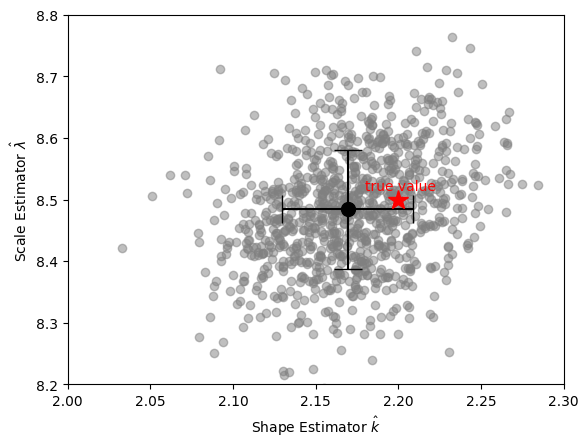

In [ ]:
# Calculate the empirical Covariance Matrix from the scattered points
cov_matrix_mc = np.cov(k_mc_results, lam_mc_results)
print("MC Covariance Matrix:")
print(cov_matrix_mc)

corr_matrix_mc = np.corrcoef(k_mc_results, lam_mc_results)
print("\nMC Correlation Matrix:")
print(corr_matrix_mc)

plt.scatter(k_mc_results, lam_mc_results, alpha=0.5, color='grey')

# plot on top the results of the likelihood fit and the true value
k_val, k_err = m_wind.values['k'], m_wind.errors['k']
lam_val, lam_err = m_wind.values['lam'], m_wind.errors['lam']

plt.errorbar(k_val, lam_val, xerr=k_err, yerr=lam_err,
             markersize=20, marker='.', capsize=10, color='k')
plt.plot(true_shape_k, true_scale_lam, marker='*', markersize=15, color='red')
plt.text(true_shape_k-0.02, true_scale_lam+0.015, 'true value', color='red')

plt.xlabel(r"Shape Estimator $\hat{k}$")
plt.ylabel(r"Scale Estimator $\hat{\lambda}$")
plt.xlim(2, 2.3)
plt.ylim(8.2, 8.8)

plt.show()
#@title { vertical-output: true}

## Method 2: The Bootstrapping Method

The Monte Carlo method is great, but it assumes that the true wind distribution is *exactly* a perfect Weibull. What if nature is slightly messier? What if our parametric model isn't perfect?

**Bootstrapping** is a data-driven method that doesn't rely on the PDF to generate toys. Instead, we generate "fake" datasets by randomly drawing measurements from our *original actual dataset*, **with replacement**. Because we put the data points back in the pool after drawing them, some original wind speeds will appear multiple times, and some will be left out.

We then fit each of these bootstrapped datasets. This gives us the variance of our estimators based purely on the statistical fluctuations present in the real data!

In [ ]:
# --- 3. Bootstrapping Method ---
n_bootstraps = 1000
k_boot_results = []
lam_boot_results = []

print("Running Bootstraps...")
for i in tqdm(range(n_bootstraps)):
    # 1. Resample the ORIGINAL data WITH replacement
    boot_data = np.random.choice(wind_speeds, size=n_events, replace=True)

    # 2. Fit the Bootstrapped Data
    nll_boot = UnbinnedNLL(boot_data, weibull_pdf)
    m_boot = Minuit(nll_boot, k=k_best, lam=lam_best)
    m_boot.limits['k'] = (0.001, None)
    m_boot.limits['lam'] = (0.001, None)

    m_boot.migrad()

    # 3. Store results if successful
    if m_boot.valid:
        k_boot_results.append(m_boot.values['k'])
        lam_boot_results.append(m_boot.values['lam'])

Running Bootstraps...


  0%|          | 0/1000 [00:00<?, ?it/s]

Bootstrap Covariance Matrix:
[[0.00149962 0.00124393]
 [0.00124393 0.00962282]]

Bootstrap Correlation Matrix:
[[1.         0.32745799]
 [0.32745799 1.        ]]


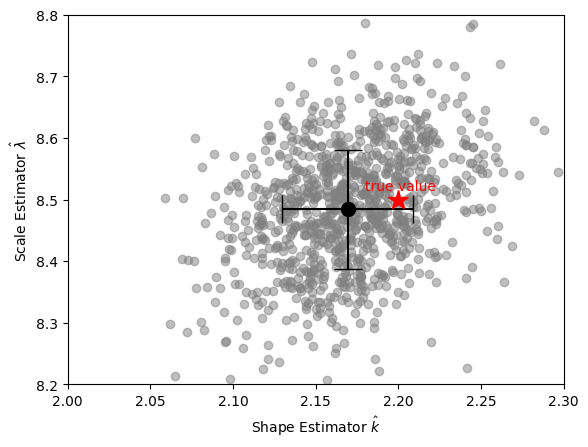

In [ ]:
# Calculate the empirical Covariance Matrix
cov_matrix_boot = np.cov(k_boot_results, lam_boot_results)
print("Bootstrap Covariance Matrix:")
print(cov_matrix_boot)

corr_matrix_mc = np.corrcoef(k_boot_results, lam_boot_results)
print("\nBootstrap Correlation Matrix:")
print(corr_matrix_mc)

plt.scatter(k_boot_results, lam_boot_results, alpha=0.5, color='grey')

# plot on top the results of the likelihood fit and the true value
plt.errorbar(k_val, lam_val, xerr=k_err, yerr=lam_err,
             markersize=20, marker='.', capsize=10, color='k')
plt.plot(true_shape_k, true_scale_lam, marker='*', markersize=15, color='red')
plt.text(true_shape_k-0.02, true_scale_lam+0.015, 'true value', color='red')

plt.xlabel(r"Shape Estimator $\hat{k}$")
plt.ylabel(r"Scale Estimator $\hat{\lambda}$")
plt.xlim(2, 2.3)
plt.ylim(8.2, 8.8)

plt.show()
#@title { vertical-output: true}

## Method 3: The Graphical Method (Likelihood Contours)

In 1D, we found the variance by scanning the parameter until the Negative Log-Likelihood (NLL) increased by exactly 0.5 (the $\Delta(-\ln L) = 0.5$ rule).

In 2D, the parameters map out a 3D likelihood valley. If we slice this valley at a specific height ($\Delta(-\ln L) = 0.5$), the cross-section forms a **contour ellipse**.
* The **width and height** of the bounding box around this ellipse give the 1D standard errors ($\sigma_k$ and $\sigma_\lambda$).
* The **tilt** of the ellipse indicates the covariance. If it tilts up and to the right, they are positively correlated. If it tilts down and to the right, they are negatively correlated. If it's perfectly straight, the covariance is zero!

Let's draw the contour using `iminuit`'s built-in profiler.

In [ ]:
# run minos
m_wind.minos()

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 9759                       │              Nfcn = 99               │
│ EDM = 2.12e-05 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ k    │   2.17    │   0.04    │   -0.04    │    0.04    │  0.001  │         │       │
│ 1 │ lam  │   8.48    │   0.10    │   -0.10    │    0.10    │  0.001  │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┐
│          │           k           │          lam          │
├──────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │   -0.04   │   0.04    │   -0.1    │    0.1    │
│  Valid   │   True    │   True    │   True    │   True    │
│ At Limit │   False   │   False   │   False   │   False   │
│ Max FCN  │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┘
┌─────┬─────────────────┐
│     │       k     lam │
├─────┼─────────────────┤
│   k │ 0.00157  0.0012 │
│ lam │  0.0012  0.0093 │
└─────┴─────────────────┘

Text(0, 0.5, '$2\\Delta\\, NLL$')

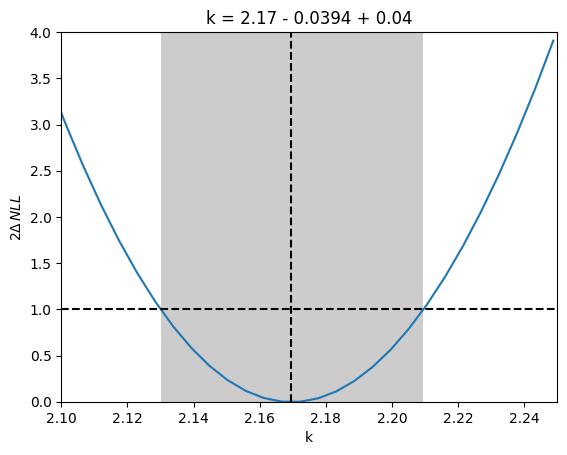

In [ ]:
# draw 1d profile likelihood
# note that the NLL is minised with respect to other parameters (profiling)
m_wind.draw_mnprofile("k");
plt.hlines(1, 2.1, 2.25, linestyles='dashed', color='black');
plt.xlim(2.1, 2.25)
plt.ylim(0, 4)
plt.ylabel(r'$2\Delta\, NLL$')
#@title { vertical-output: true}

Text(0, 0.5, '$2\\Delta\\, NLL$')

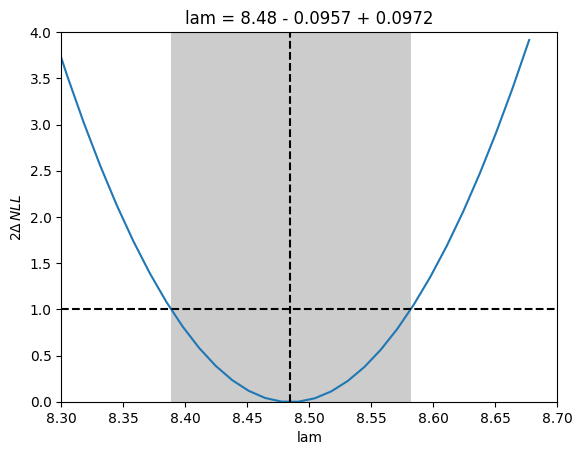

In [ ]:
# draw 1d profile likelihood
# note that the NLL is minised with respect to other parameters (profiling)
m_wind.draw_mnprofile("lam");
plt.hlines(1, 8.3, 8.7, linestyles='dashed', color='black');
plt.xlim(8.3, 8.7)
plt.ylim(0, 4)
plt.ylabel(r'$2\Delta\, NLL$')
#@title { vertical-output: true}

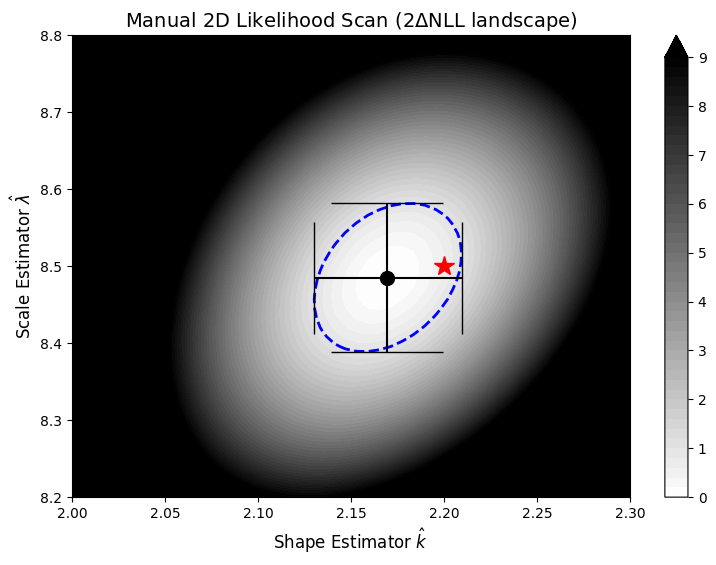

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get the best-fit values and the absolute minimum NLL
k_val = m_wind.values['k']
lam_val = m_wind.values['lam']
min_nll = m_wind.fval  # The minimum Negative Log-Likelihood found by Migrad

# -------------------------------------------------------------------
# MANUAL 2D LIKELIHOOD SCAN
# -------------------------------------------------------------------
# Define the grid of parameter values to scan
k_scan = np.linspace(2.0, 2.3, 50)
lam_scan = np.linspace(8.2, 8.8, 50)
K, LAM = np.meshgrid(k_scan, lam_scan)

# Evaluate the NLL at every point on the grid
nll_grid = np.zeros_like(K)
for i in range(K.shape[0]):
    for j in range(K.shape[1]):
        # nll_wind is the cost function we passed to Minuit earlier
        nll_grid[i, j] = nll_wind(K[i, j], LAM[i, j])

delta_nll2 = (nll_grid - min_nll)

plt.figure(figsize=(9, 6))
# Draw the colored shade for the 2*DeltaNLL landscape
# We limit the color scale (vmax) so the colors don't wash out near the minimum
contour_shade = plt.contourf(K, LAM, delta_nll2, levels=np.linspace(0, 9, 46),
                             cmap='binary', extend='max')
plt.colorbar(contour_shade)

# Draw the specific contour line where 2*DeltaNLL = 1
contour_line = plt.contour(K, LAM, delta_nll2, levels=[1.0],
                           colors='blue', linestyles='dashed', linewidths=2)

# -------------------------------------------------------------------
# OVERLAYING THE ERRORS AND TRUE VALUES
# -------------------------------------------------------------------
# Extract MINOS errors (taking the absolute value of the lower bounds)
k_err_lower = abs(m_wind.merrors['k'].lower)
k_err_upper = m_wind.merrors['k'].upper
lam_err_lower = abs(m_wind.merrors['lam'].lower)
lam_err_upper = m_wind.merrors['lam'].upper

# Draw the point and asymmetric error bars
plt.errorbar(k_val, lam_val,
             xerr=[[k_err_lower], [k_err_upper]],
             yerr=[[lam_err_lower], [lam_err_upper]],
             markersize=20, marker='.', capsize=40, color='k',
             label='MLE + MINOS errors', zorder=5)

# Plot the true value
plt.plot(true_shape_k, true_scale_lam, marker='*', markersize=15,
         color='red', label='True Value')

plt.xlim(2.0, 2.3)
plt.ylim(8.2, 8.8)

plt.xlabel(r"Shape Estimator $\hat{k}$", fontsize=12)
plt.ylabel(r"Scale Estimator $\hat{\lambda}$", fontsize=12)
plt.title(r"Manual 2D Likelihood Scan ($2\Delta$NLL landscape)", fontsize=14)
plt.show()
#@title { vertical-output: true}

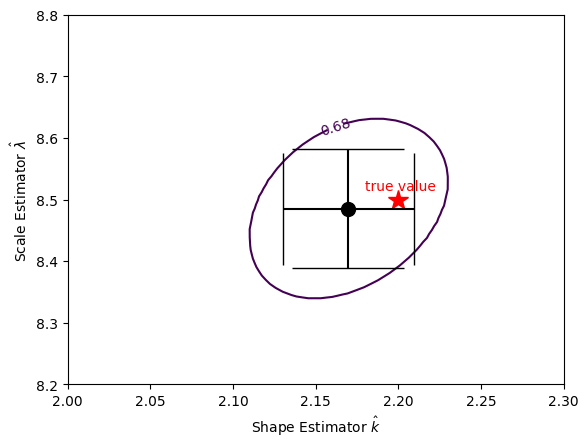

In [ ]:
# First, ensure MINOS has been run to calculate the asymmetric errors!
m_wind.minos()

# draw_mncontour dynamically profiles the likelihood space
m_wind.draw_mncontour('k', 'lam', cl=0.68)

# Get the best-fit values
k_val = m_wind.values['k']
lam_val = m_wind.values['lam']

# Extract MINOS errors (taking the absolute value of the lower bounds)
k_err_lower = abs(m_wind.merrors['k'].lower)
k_err_upper = m_wind.merrors['k'].upper
lam_err_lower = abs(m_wind.merrors['lam'].lower)
lam_err_upper = m_wind.merrors['lam'].upper

# Draw the point and asymmetric error bars
plt.errorbar(k_val, lam_val,
             xerr=[[k_err_lower], [k_err_upper]],
             yerr=[[lam_err_lower], [lam_err_upper]],
             markersize=20, marker='.', capsize=40, color='k',
             label='MLE + MINOS errors', zorder=5)

# Plot the true value
plt.plot(true_shape_k, true_scale_lam, marker='*', markersize=15, color='red')
plt.text(true_shape_k - 0.02, true_scale_lam + 0.015, 'true value', color='red')

plt.xlim(2, 2.3)
plt.ylim(8.2, 8.8)

plt.xlabel(r"Shape Estimator $\hat{k}$")
plt.ylabel(r"Scale Estimator $\hat{\lambda}$")
plt.show()
#@title { vertical-output: true}

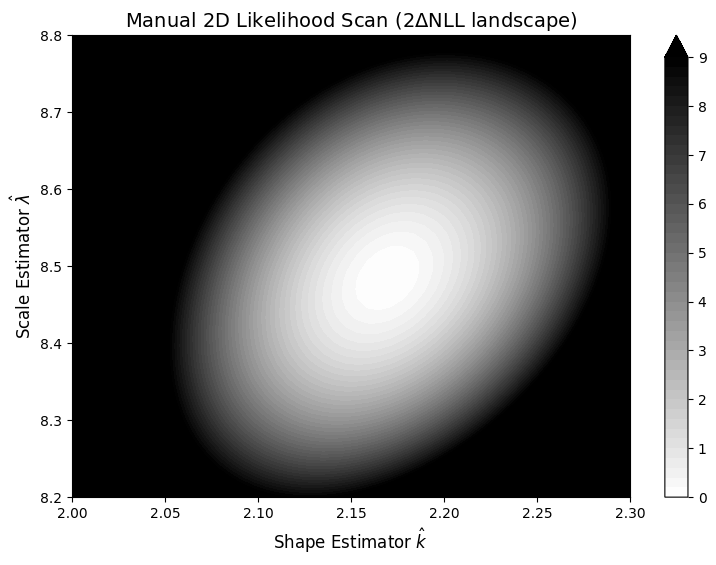

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get the best-fit values and the absolute minimum NLL
k_val = m_wind.values['k']
lam_val = m_wind.values['lam']
min_nll = m_wind.fval  # The minimum Negative Log-Likelihood found by Migrad

# -------------------------------------------------------------------
# MANUAL 2D LIKELIHOOD SCAN
# -------------------------------------------------------------------
# Define the grid of parameter values to scan
k_scan = np.linspace(2.0, 2.3, 50)
lam_scan = np.linspace(8.2, 8.8, 50)
K, LAM = np.meshgrid(k_scan, lam_scan)

# Evaluate the NLL at every point on the grid
nll_grid = np.zeros_like(K)
for i in range(K.shape[0]):
    for j in range(K.shape[1]):
        # nll_wind is the cost function we passed to Minuit earlier
        nll_grid[i, j] = nll_wind(K[i, j], LAM[i, j])

delta_nll2 = (nll_grid - min_nll)

plt.figure(figsize=(9, 6))
# Draw the colored shade for the 2*DeltaNLL landscape
# We limit the color scale (vmax) so the colors don't wash out near the minimum
contour_shade = plt.contourf(K, LAM, delta_nll2, levels=np.linspace(0, 9, 46),
                             cmap='binary', extend='max')
plt.colorbar(contour_shade)


plt.xlim(2.0, 2.3)
plt.ylim(8.2, 8.8)

plt.xlabel(r"Shape Estimator $\hat{k}$", fontsize=12)
plt.ylabel(r"Scale Estimator $\hat{\lambda}$", fontsize=12)
plt.title(r"Manual 2D Likelihood Scan ($2\Delta$NLL landscape)", fontsize=14)
plt.show()
#@title { vertical-output: true}